In [1]:
!pip -q install pycoingecko pandas numpy matplotlib


In [2]:
from pycoingecko import CoinGeckoAPI
import pandas as pd
import time

cg = CoinGeckoAPI()


top_n = 50
markets = cg.get_coins_markets(vs_currency="usd", order="market_cap_desc", per_page=top_n, page=1)
coin_ids = [c["id"] for c in markets]

coin_ids[:10], len(coin_ids)


(['bitcoin',
  'ethereum',
  'tether',
  'ripple',
  'binancecoin',
  'solana',
  'usd-coin',
  'tron',
  'staked-ether',
  'dogecoin'],
 50)

In [3]:
def fetch_coin_market_chart(coin_id: str, vs="usd", days=365):
    data = cg.get_coin_market_chart_by_id(id=coin_id, vs_currency=vs, days=days)
    
    prices = pd.DataFrame(data["prices"], columns=["ts", "price"])
    mcap   = pd.DataFrame(data["market_caps"], columns=["ts", "market_cap"])
    vol    = pd.DataFrame(data["total_volumes"], columns=["ts", "volume"])

    df = prices.merge(mcap, on="ts").merge(vol, on="ts")
    df["date"] = pd.to_datetime(df["ts"], unit="ms").dt.date
    df["coin_id"] = coin_id
    return df[["date", "coin_id", "price", "market_cap", "volume"]]

rows = []
for i, cid in enumerate(coin_ids, 1):
    try:
        rows.append(fetch_coin_market_chart(cid, days=365))
        time.sleep(1.2)  
        print(f"{i}/{len(coin_ids)} OK: {cid}")
    except Exception as e:
        print(f"{i}/{len(coin_ids)} FAIL: {cid} -> {e}")

df = pd.concat(rows, ignore_index=True)
df.head(), df.shape


1/50 OK: bitcoin
2/50 OK: ethereum
3/50 OK: tether
4/50 OK: ripple
5/50 OK: binancecoin
6/50 OK: solana
7/50 OK: usd-coin
8/50 OK: tron
9/50 OK: staked-ether
10/50 OK: dogecoin
11/50 OK: figure-heloc
12/50 OK: cardano
13/50 OK: bitcoin-cash
14/50 OK: wrapped-steth
15/50 OK: whitebit
16/50 OK: wrapped-beacon-eth
17/50 OK: wrapped-bitcoin
18/50 OK: wrapped-eeth
19/50 OK: usds
20/50 OK: chainlink
21/50 OK: binance-bridged-usdt-bnb-smart-chain
22/50 OK: monero
23/50 OK: leo-token
24/50 OK: weth
25/50 OK: stellar
26/50 OK: coinbase-wrapped-btc
27/50 OK: sui
28/50 OK: ethena-usde
29/50 OK: zcash
30/50 OK: litecoin
31/50 OK: avalanche-2
32/50 OK: hyperliquid
33/50 OK: shiba-inu
34/50 OK: hedera-hashgraph
35/50 OK: canton-network
36/50 OK: usdt0
37/50 OK: world-liberty-financial
38/50 OK: susds
39/50 OK: dai
40/50 OK: the-open-network
41/50 OK: crypto-com-chain
42/50 OK: ethena-staked-usde
43/50 OK: paypal-usd
44/50 OK: polkadot
45/50 OK: uniswap
46/50 OK: usd1-wlfi
47/50 OK: mantle
48/50 OK: 

(         date  coin_id         price    market_cap        volume
 0  2025-01-11  bitcoin  94736.626742  1.876837e+12  6.343366e+10
 1  2025-01-12  bitcoin  94559.551672  1.874286e+12  1.783642e+10
 2  2025-01-13  bitcoin  94454.770896  1.870315e+12  1.960893e+10
 3  2025-01-14  bitcoin  94456.349375  1.870609e+12  7.632833e+10
 4  2025-01-15  bitcoin  96574.077688  1.912603e+12  5.124173e+10,
 (17009, 5))

In [4]:
df.to_csv("crypto_top50_365d.csv", index=False)
df.to_parquet("crypto_top50_365d.parquet", index=False)


In [5]:
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["coin_id", "date"])

df["return_1d"] = df.groupby("coin_id")["price"].pct_change()
summary = df.groupby("coin_id").agg(
    avg_return=("return_1d", "mean"),
    vol=("return_1d", "std"),
    last_price=("price", "last"),
    days=("date", "nunique")
).sort_values("vol", ascending=False)

summary.head(10)


,avg_return,vol,last_price,days
coin_id,,,,
figure-heloc,0.023131,0.317409,1.007256,138
memecore,0.025723,0.137940,1.710537,192
rain,0.015110,0.126746,0.008692,122
canton-network,0.004987,0.085955,0.129750,62
zcash,0.008136,0.073671,378.475173,365
world-liberty-financial,-0.000631,0.060812,0.168034,132
cardano,-0.000862,0.058792,0.390615,365
uniswap,-0.000969,0.057046,5.505849,365
bittensor,0.000303,0.055937,280.148603,365


In [6]:
top10 = coin_ids[:10]
wide = df[df["coin_id"].isin(top10)].pivot_table(index="date", columns="coin_id", values="return_1d")
corr = wide.corr()
corr


coin_id,binancecoin,bitcoin,dogecoin,ethereum,ripple,solana,staked-ether,tether,tron,usd-coin
coin_id,,,,,,,,,,
binancecoin,1.000000,0.654276,0.693486,0.701320,0.579316,0.647411,0.701882,0.144337,0.424498,0.076608
bitcoin,0.654276,1.000000,0.801827,0.817164,0.785827,0.796963,0.816369,0.387145,0.452931,0.091571
dogecoin,0.693486,0.801827,1.000000,0.855699,0.784166,0.802874,0.855417,0.268096,0.498446,0.105495
ethereum,0.701320,0.817164,0.855699,1.000000,0.741861,0.789486,0.999586,0.275103,0.503428,0.054541
ripple,0.579316,0.785827,0.784166,0.741861,1.000000,0.776844,0.739701,0.314516,0.439224,0.103621
solana,0.647411,0.796963,0.802874,0.789486,0.776844,1.000000,0.786418,0.227088,0.438825,0.096076
staked-ether,0.701882,0.816369,0.855417,0.999586,0.739701,0.786418,1.000000,0.275918,0.503680,0.055239
tether,0.144337,0.387145,0.268096,0.275103,0.314516,0.227088,0.275918,1.000000,0.157357,0.101784
tron,0.424498,0.452931,0.498446,0.503428,0.439224,0.438825,0.503680,0.157357,1.000000,0.071417


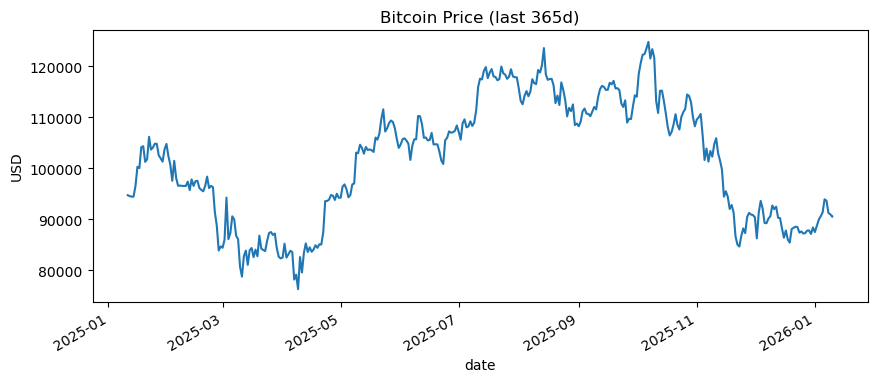

In [7]:
import matplotlib.pyplot as plt

btc = df[df["coin_id"]=="bitcoin"].set_index("date")["price"]
btc.plot(figsize=(10,4))
plt.title("Bitcoin Price (last 365d)")
plt.ylabel("USD")
plt.show()


In [8]:
out = summary.reset_index().rename(columns={"coin_id":"coin"})
out["sharpe_like"] = out["avg_return"] / out["vol"]  # risksiz faiz yok, o yüzden "like"
out.sort_values("sharpe_like", ascending=False).head(15)


,coin,avg_return,vol,last_price,days,sharpe_like
1,memecore,0.025723,0.137940,1.710537,192,0.186481
43,ethena-staked-usde,0.000177,0.001057,1.214255,365,0.167775
2,rain,0.015110,0.126746,0.008692,122,0.119215
4,zcash,0.008136,0.073671,378.475173,365,0.110438
31,monero,0.002904,0.033010,470.827883,365,0.087961
32,whitebit,0.002230,0.028579,55.261440,355,0.078027
0,figure-heloc,0.023131,0.317409,1.007256,138,0.072874
3,canton-network,0.004987,0.085955,0.129750,62,0.058015
39,susds,0.000137,0.002777,1.079139,365,0.049244
29,bitcoin-cash,0.001714,0.038699,642.901895,365,0.044278


In [9]:
out.to_csv("crypto_risk_return_summary.csv", index=False)


In [10]:
out["avg_return_pct"] = out["avg_return"] * 100
out["vol_pct"] = out["vol"] * 100

out[["coin", "avg_return_pct", "vol_pct", "sharpe_like"]].sort_values(
    "sharpe_like", ascending=False
).head(10)


,coin,avg_return_pct,vol_pct,sharpe_like
1,memecore,2.572323,13.794000,0.186481
43,ethena-staked-usde,0.017737,0.105719,0.167775
2,rain,1.511008,12.674631,0.119215
4,zcash,0.813603,7.367059,0.110438
31,monero,0.290362,3.301039,0.087961
32,whitebit,0.222989,2.857850,0.078027
0,figure-heloc,2.313069,31.740882,0.072874
3,canton-network,0.498667,8.595461,0.058015
39,susds,0.013677,0.277745,0.049244
29,bitcoin-cash,0.171352,3.869918,0.044278


In [5]:
import os
os.listdir()


['.ipynb_checkpoints',
 'crypto_eda.ipynb',
 'crypto_risk_return_summary.csv',
 'crypto_top50_365d.csv',
 'crypto_top50_365d.parquet']

In [6]:
import pandas as pd
import numpy as np
import sqlite3

df = pd.read_parquet("crypto_top50_365d.parquet")
print("Loaded:", df.shape)
df.head()



Loaded: (17009, 5)


,date,coin_id,price,market_cap,volume
0,2025-01-11,bitcoin,94736.626742,1.876837e+12,6.343366e+10
1,2025-01-12,bitcoin,94559.551672,1.874286e+12,1.783642e+10
2,2025-01-13,bitcoin,94454.770896,1.870315e+12,1.960893e+10
3,2025-01-14,bitcoin,94456.349375,1.870609e+12,7.632833e+10
4,2025-01-15,bitcoin,96574.077688,1.912603e+12,5.124173e+10


In [7]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")

for col in ["price", "market_cap", "volume"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

if "return_1d" not in df.columns:
    df = df.sort_values(["coin_id", "date"])
    df["return_1d"] = df.groupby("coin_id")["price"].pct_change()
else:
    df["return_1d"] = pd.to_numeric(df["return_1d"], errors="coerce")


df = df.dropna(subset=["date", "coin_id", "price", "return_1d"])


df = df.drop_duplicates(subset=["coin_id", "date"])


df["abs_return"] = df["return_1d"].abs()
q99 = df["abs_return"].quantile(0.99)
df["is_outlier"] = (df["abs_return"] > q99).astype(int)


df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["year_month"] = df["date"].dt.strftime("%Y-%m")

print("After clean:", df.shape)


After clean: (16909, 11)


In [8]:
con = sqlite3.connect("crypto.db")
df.to_sql("crypto_prices", con, if_exists="replace", index=False)

con.execute("CREATE INDEX IF NOT EXISTS idx_coin_date ON crypto_prices(coin_id, date);")
con.commit()

rows = con.execute("SELECT COUNT(*) FROM crypto_prices;").fetchone()[0]
coins = con.execute("SELECT COUNT(DISTINCT coin_id) FROM crypto_prices;").fetchone()[0]
print("Rows:", rows, "| Coins:", coins)


Rows: 16909 | Coins: 50


In [11]:
try:
    q("""
    WITH base AS (
      SELECT coin_id, name, symbol, return_1d AS r
      FROM crypto_prices
      WHERE r IS NOT NULL
    )
    SELECT
      coin_id, name, symbol,
      AVG(r) AS avg_return,
      SQRT(AVG(r*r) - AVG(r)*AVG(r)) AS vol,
      AVG(r) / NULLIF(SQRT(AVG(r*r) - AVG(r)*AVG(r)), 0) AS sharpe_like
    FROM base
    GROUP BY coin_id, name, symbol
    ORDER BY sharpe_like DESC
    LIMIT 15;
    """)
except Exception as e:
    print("ERROR:", e)


ERROR: Execution failed on sql '
    WITH base AS (
      SELECT coin_id, name, symbol, return_1d AS r
      FROM crypto_prices
      WHERE r IS NOT NULL
    )
    SELECT
      coin_id, name, symbol,
      AVG(r) AS avg_return,
      SQRT(AVG(r*r) - AVG(r)*AVG(r)) AS vol,
      AVG(r) / NULLIF(SQRT(AVG(r*r) - AVG(r)*AVG(r)), 0) AS sharpe_like
    FROM base
    GROUP BY coin_id, name, symbol
    ORDER BY sharpe_like DESC
    LIMIT 15;
    ': no such column: name


In [12]:
q("PRAGMA table_info(crypto_prices);")


,cid,name,type,notnull,dflt_value,pk
0,0,date,TIMESTAMP,0,None,0
1,1,coin_id,TEXT,0,None,0
2,2,price,REAL,0,None,0
3,3,market_cap,REAL,0,None,0
4,4,volume,REAL,0,None,0
5,5,return_1d,REAL,0,None,0
6,6,abs_return,REAL,0,None,0
7,7,is_outlier,INTEGER,0,None,0
8,8,year,INTEGER,0,None,0
9,9,month,INTEGER,0,None,0


In [14]:
import math
con.create_function("SQRT", 1, lambda x: None if x is None else math.sqrt(x))


In [15]:
q("""
WITH base AS (
  SELECT coin_id, return_1d AS r
  FROM crypto_prices
  WHERE r IS NOT NULL
),
stats AS (
  SELECT
    coin_id,
    AVG(r) AS avg_return,
    AVG(r*r) AS avg_r2
  FROM base
  GROUP BY coin_id
)
SELECT
  coin_id,
  avg_return,
  SQRT(
    CASE
      WHEN (avg_r2 - avg_return*avg_return) < 0 THEN 0
      ELSE (avg_r2 - avg_return*avg_return)
    END
  ) AS vol,
  avg_return /
  NULLIF(
    SQRT(
      CASE
        WHEN (avg_r2 - avg_return*avg_return) < 0 THEN 0
        ELSE (avg_r2 - avg_return*avg_return)
      END
    ), 0
  ) AS sharpe_like
FROM stats
ORDER BY sharpe_like DESC
LIMIT 15;
""")


,coin_id,avg_return,vol,sharpe_like
0,memecore,0.025842,0.137930,0.187359
1,ethena-staked-usde,0.000178,0.001057,0.168147
2,rain,0.014949,0.126734,0.117955
3,zcash,0.008416,0.073477,0.114533
4,monero,0.002790,0.032939,0.084695
5,whitebit,0.002224,0.028578,0.077836
6,figure-heloc,0.023484,0.317382,0.073994
7,susds,0.000160,0.002742,0.058386
8,canton-network,0.004521,0.085876,0.052649
9,bitcoin-cash,0.001679,0.038694,0.043395


In [16]:
q("""
SELECT
  coin_id,
  year_month,
  AVG(price) AS avg_price,
  AVG(return_1d) AS avg_return,
  SQRT(AVG(return_1d*return_1d) - AVG(return_1d)*AVG(return_1d)) AS vol,
  SUM(volume) AS total_volume,
  AVG(market_cap) AS avg_market_cap
FROM crypto_prices
WHERE return_1d IS NOT NULL
GROUP BY coin_id, year_month
ORDER BY coin_id, year_month;
""")


,coin_id,year_month,avg_price,avg_return,vol,total_volume,avg_market_cap
0,avalanche-2,2025-01,36.407982,-0.002514,0.041902,9.841031e+09,1.498183e+10
1,avalanche-2,2025-02,25.482703,-0.013715,0.048568,1.313230e+10,1.051198e+10
2,avalanche-2,2025-03,20.038198,-0.003646,0.063285,1.229120e+10,8.303621e+09
3,avalanche-2,2025-04,19.578399,0.005630,0.050639,1.007115e+10,8.139148e+09
4,avalanche-2,2025-05,22.644483,-0.000198,0.048492,1.439158e+10,9.496509e+09
...,...,...,...,...,...,...,...
603,zcash,2025-09,50.210437,0.021485,0.057838,2.497119e+09,8.175853e+08
604,zcash,2025-10,228.615732,0.062267,0.158066,2.442785e+10,3.733369e+09
605,zcash,2025-11,537.890830,0.014345,0.098370,6.205862e+10,8.831468e+09
606,zcash,2025-12,420.845607,0.007584,0.078351,2.645588e+10,6.920581e+09


In [17]:
q("""
SELECT
  coin_id,
  SUM(CASE WHEN is_outlier = 1 THEN 1 ELSE 0 END) AS outlier_days,
  COUNT(*) AS total_days,
  1.0 * SUM(CASE WHEN is_outlier = 1 THEN 1 ELSE 0 END) / COUNT(*) AS outlier_ratio
FROM crypto_prices
GROUP BY coin_id
ORDER BY outlier_ratio DESC
LIMIT 20;
""")


,coin_id,outlier_days,total_days,outlier_ratio
0,memecore,25,191,0.130890
1,canton-network,6,61,0.098361
2,zcash,18,364,0.049451
3,world-liberty-financial,6,131,0.045802
4,rain,4,121,0.033058
5,figure-heloc,4,137,0.029197
6,bittensor,9,364,0.024725
7,mantle,8,364,0.021978
8,sui,8,364,0.021978
9,uniswap,7,364,0.019231


In [18]:
risk = q("""
WITH base AS (
  SELECT coin_id, return_1d AS r
  FROM crypto_prices
  WHERE r IS NOT NULL
),
stats AS (
  SELECT coin_id, AVG(r) AS avg_return, AVG(r*r) AS avg_r2
  FROM base
  GROUP BY coin_id
)
SELECT
  coin_id,
  avg_return,
  SQRT(CASE WHEN (avg_r2 - avg_return*avg_return) < 0 THEN 0 ELSE (avg_r2 - avg_return*avg_return) END) AS vol,
  avg_return / NULLIF(SQRT(CASE WHEN (avg_r2 - avg_return*avg_return) < 0 THEN 0 ELSE (avg_r2 - avg_return*avg_return) END), 0) AS sharpe_like
FROM stats
ORDER BY sharpe_like DESC;
""")

monthly = q("""
SELECT
  coin_id,
  year_month,
  AVG(price) AS avg_price,
  AVG(return_1d) AS avg_return,
  SQRT(AVG(return_1d*return_1d) - AVG(return_1d)*AVG(return_1d)) AS vol,
  SUM(volume) AS total_volume,
  AVG(market_cap) AS avg_market_cap
FROM crypto_prices
WHERE return_1d IS NOT NULL
GROUP BY coin_id, year_month;
""")

outliers = q("""
SELECT
  coin_id,
  SUM(CASE WHEN is_outlier = 1 THEN 1 ELSE 0 END) AS outlier_days,
  COUNT(*) AS total_days,
  1.0 * SUM(CASE WHEN is_outlier = 1 THEN 1 ELSE 0 END) / COUNT(*) AS outlier_ratio
FROM crypto_prices
GROUP BY coin_id;
""")

risk.to_csv("sql_risk_return.csv", index=False)
monthly.to_csv("sql_monthly_trends.csv", index=False)
outliers.to_csv("sql_outliers.csv", index=False)

print("Exported: sql_risk_return.csv, sql_monthly_trends.csv, sql_outliers.csv")


Exported: sql_risk_return.csv, sql_monthly_trends.csv, sql_outliers.csv
